# Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from tqdm.auto import tqdm


In [16]:
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', 20)

In [17]:
%matplotlib inline  

# Вопросы


* Целевая переменная 
* block_well_id
* лаги допустимо ли
* колонки `EI`
* В общем и целом колонки
* вторая модель
* единицы измерения

# Предпросмотр и начальная обработка

In [6]:
df = pd.read_csv("datasets/dataset_1.csv")
df.head(3)

,id,time,processing_time,lon,lat,height,depth,course,angle,num_sattelites,...,speed,n/p,EI,EI 0-1,EI 1-2,EI 2-3,EI 3-4,EI 4-5,EI 5-6,EI 6-7
0,23061521,2025-10-07 22:18:02,2025-10-07 22:18:09.425,60.921372,53.208426,205.072378,4.5753,208,92.2,37,...,NaN,0.011135,6.580100e+04,7826.0000,14913.00000,17481.0,9998.0,5353.0,4888.0,2660.0
1,23061529,2025-10-07 22:18:08,2025-10-07 22:18:14.495,60.921372,53.208426,205.061214,4.6965,256,93.4,37,...,0.02020,0.008207,8.723352e+11,0.0202,0.00000,0.0,0.0,0.0,0.0,0.0
2,23061535,2025-10-07 22:18:13,2025-10-07 22:18:19.239,60.921372,53.208427,205.078345,4.8783,359,93.0,37,...,0.03636,0.005347,1.002123e+12,0.0000,0.03636,0.0,0.0,0.0,0.0,0.0


(array([5.5550e+04, 5.6944e+04, 4.1898e+04, 6.9650e+03, 1.7580e+03,
        2.0650e+03, 6.5100e+02, 2.3000e+01, 2.1000e+01, 9.1000e+01]),
 array([-1.1211 ,  5.87214, 12.86538, 19.85862, 26.85186, 33.8451 ,
        40.83834, 47.83158, 54.82482, 61.81806, 68.8113 ]),
 <BarContainer object of 10 artists>)

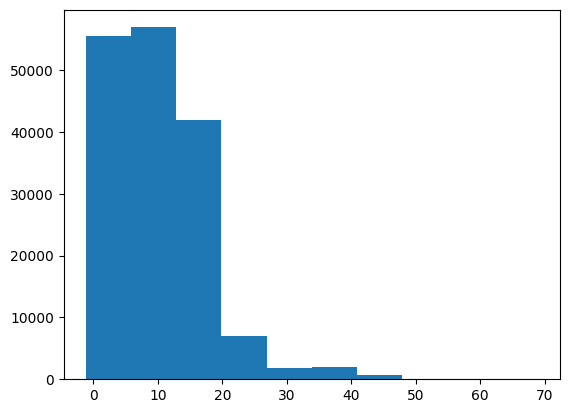

In [12]:
plt.hist(df['depth'])

<h1> профайлер

In [ ]:

profile = ProfileReport(
    df,
    title="Drilling Data Profiling",
    explorative=True
)

profile.to_file("drilling_profile.html")

In [45]:
df.head(5)

,id,time,processing_time,lon,lat,height,depth,course,angle,num_sattelites,moving_type,rotation,rod_change,pressure_air,pressure_axis,pressure_rotation,electric_rotation,electric_pressure_axis,voltage_rotation,voltage_pressure_axis,time_stamp,sequence_id,block_well_id,rig_id,well_id,drilling_speed,rtk_status,d_depth,d_time,speed,n/p,EI,EI 0-1,EI 1-2,EI 2-3,EI 3-4,EI 4-5,EI 5-6,EI 6-7
0,23061521,2025-10-07 22:18:02,2025-10-07 22:18:09.425,60.921372,53.208426,205.072378,4.5753,208,92.2,37,1,107.010,0.0,502,9610,9741,NaN,NaN,NaN,NaN,NaN,6,NaN,49,25512,NaN,True,0.4545,NaN,NaN,0.011135,6.580100e+04,7826.0000,14913.00000,17481.0,9998.0,5353.0,4888.0,2660.0
1,23061529,2025-10-07 22:18:08,2025-10-07 22:18:14.495,60.921372,53.208426,205.061214,4.6965,256,93.4,37,1,104.892,0.0,497,12781,13144,NaN,NaN,NaN,NaN,NaN,6,NaN,49,25512,NaN,True,0.1212,6.0,0.02020,0.008207,8.723352e+11,0.0202,0.00000,0.0,0.0,0.0,0.0,0.0
2,23061535,2025-10-07 22:18:13,2025-10-07 22:18:19.239,60.921372,53.208427,205.078345,4.8783,359,93.0,37,1,101.430,0.0,501,18971,18936,NaN,NaN,NaN,NaN,NaN,6,NaN,49,25512,NaN,True,0.1818,5.0,0.03636,0.005347,1.002123e+12,0.0000,0.03636,0.0,0.0,0.0,0.0,0.0
3,23061542,2025-10-07 22:18:18,2025-10-07 22:18:24.208,60.921373,53.208425,205.054763,5.0298,170,92.1,37,1,101.430,0.0,544,20153,18184,NaN,NaN,NaN,NaN,NaN,6,NaN,49,25512,NaN,True,0.1515,5.0,0.03030,0.005033,1.226741e+12,0.0000,0.03030,0.0,0.0,0.0,0.0,0.0
4,23061551,2025-10-07 22:18:23,2025-10-07 22:18:29.385,60.921372,53.208425,205.065585,5.1813,218,93.0,37,1,102.714,0.0,559,20162,17445,NaN,NaN,NaN,NaN,NaN,6,NaN,49,25512,NaN,True,0.1515,5.0,0.03030,0.005094,1.192317e+12,0.0000,0.03030,0.0,0.0,0.0,0.0,0.0


## Очистка и отбор признаков


### 1. Константные признаки
- `rig_id` — содержит единственное значение (49)
- `rtk_status` — содержит единственное значение (True)

отсутствие вариативности, не несут информации для модели.

---

### 2. Идентификаторы
- `id`
- `well_id`
- `sequence_id`
- `processing_time`

уникальные идентификаторы, не отражают физику процесса.
Используются только для групповой валидации.

---

### 3. Почти полностью пропущенные признаки
- `block_well_id` 86.8% nan ???
- `electric_rotation` nan
- `electric_pressure_axis` nan
- `voltage_rotation` nan
- `voltage_pressure_axis` nan
- `time_stamp` nan
- `drilling_speed` nan



---

### 4. Географические признаки
- `lat`
- `lon`
- `height`

пространственные координаты 



In [143]:
def nums(ale):
    out = [1,2]
    ale = out
    return ale
print(nums([1,2,3]))

[1, 2]


In [ ]:
# drop = [
#  'id',
#  'rig_id' ,                 
#  'rtk_status',
#  'time_stamp', 'electric_rotation', 'electric_pressure_axis',
#  'voltage_rotation','voltage_pressure_axis','drilling_speed',
#  'lon', 'lat'
# ]
# df = df.drop(columns=drop, errors='ignore')


# Исследование датасета

- колонка `EI` вычисляется с помощью формулы ...

In [51]:

test = df['pressure_axis'] * df['rotation'] / df['speed']

correlation = df['EI'].corr(test)

print(correlation)


0.9979755926979693


In [52]:
pd.concat([test,df['EI']], axis=1)

,0,EI
0,NaN,6.580100e+04
1,6.636756e+07,8.723352e+11
2,5.292158e+07,1.002123e+12
3,6.746267e+07,1.226741e+12
4,6.834718e+07,1.192317e+12
...,...,...
165961,1.178889e+08,1.022096e+12
165962,5.957040e+07,5.273767e+11
165963,5.939390e+07,5.330008e+11
165964,5.827563e+07,5.979080e+11


# попытка обучения

In [116]:
df_learn = df.copy()

In [117]:
df_learn = df_learn[df_learn['speed'].notna()]
df_learn = df_learn[df_learn['speed'] > 0]


In [118]:
drop = [
 'id',
 'rig_id' ,                 
 'rtk_status',
 'time_stamp', 'electric_rotation', 'electric_pressure_axis',
 'voltage_rotation','voltage_pressure_axis','drilling_speed',
 'lon', 'lat', 'EI', 'EI 0-1', 'EI 1-2', 'EI 2-3', 'EI 3-4', 'EI 4-5', 'EI 5-6', 'EI 6-7', 'block_well_id'
]
df_learn.drop(columns=drop, inplace=True)

In [119]:
df_learn.head(5)

,time,processing_time,height,depth,course,angle,num_sattelites,moving_type,rotation,rod_change,pressure_air,pressure_axis,pressure_rotation,sequence_id,well_id,d_depth,d_time,speed,n/p
1,2025-10-07 22:18:08,2025-10-07 22:18:14.495,205.061214,4.6965,256,93.4,37,1,104.892,0.0,497,12781,13144,6,25512,0.1212,6.0,0.020200,0.008207
2,2025-10-07 22:18:13,2025-10-07 22:18:19.239,205.078345,4.8783,359,93.0,37,1,101.430,0.0,501,18971,18936,6,25512,0.1818,5.0,0.036360,0.005347
3,2025-10-07 22:18:18,2025-10-07 22:18:24.208,205.054763,5.0298,170,92.1,37,1,101.430,0.0,544,20153,18184,6,25512,0.1515,5.0,0.030300,0.005033
4,2025-10-07 22:18:23,2025-10-07 22:18:29.385,205.065585,5.1813,218,93.0,37,1,102.714,0.0,559,20162,17445,6,25512,0.1515,5.0,0.030300,0.005094
5,2025-10-07 22:18:50,2025-10-07 22:18:58.036,205.090648,5.3934,341,94.3,37,1,47.724,0.0,558,1233,10808,6,25512,0.2121,27.0,0.007856,0.038706


In [120]:
df_learn = df_learn.sort_values(['well_id', 'time'])

In [121]:
for lag in [1, 2, 3]:
    df_learn[f'speed_lag{lag}'] = df_learn.groupby('well_id')['speed'].shift(lag)
    df_learn[f'pressure_axis_lag{lag}'] = df_learn.groupby('well_id')['pressure_axis'].shift(lag)
    df_learn[f'rotation_lag{lag}'] = df_learn.groupby('well_id')['rotation'].shift(lag)

In [122]:
df_learn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165552 entries, 1 to 165965
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   time                165552 non-null  object 
 1   processing_time     165552 non-null  object 
 2   height              165552 non-null  float64
 3   depth               165552 non-null  float64
 4   course              165552 non-null  int64  
 5   angle               165552 non-null  float64
 6   num_sattelites      165552 non-null  int64  
 7   moving_type         165552 non-null  int64  
 8   rotation            165552 non-null  float64
 9   rod_change          165552 non-null  float64
 10  pressure_air        165552 non-null  int64  
 11  pressure_axis       165552 non-null  int64  
 12  pressure_rotation   165552 non-null  int64  
 13  sequence_id         165552 non-null  int64  
 14  well_id             165552 non-null  int64  
 15  d_depth             165552 non-null  fl

In [123]:




df_learn = df_learn.dropna()


In [124]:
df_learn.shape

(163038, 28)

In [ ]:
features = [
    'pressure_axis',
    'pressure_rotation',
    'rotation',
    'depth',
    'angle',
    'course',
    'speed_lag1',
    'speed_lag2',
    'speed_lag3'
]

X = df_learn[features]
y = df_learn['speed']
groups = df_learn['well_id']

In [132]:
df_learn['well_id'].value_counts()


well_id
26204    621
26377    602
26195    582
26499    581
26466    557
        ... 
29484      1
29485      1
26918      1
26578      1
26448      1
Name: count, Length: 815, dtype: int64

In [133]:
gkf = GroupKFold(n_splits=5)
scores = []

splits = list(gkf.split(X, y, groups))

for fold, (train_idx, test_idx) in enumerate(tqdm(splits, desc="Training folds")):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    score = r2_score(y_test, preds)
    scores.append(score)

print("R2 scores:", scores)
print("Mean R2:", np.mean(scores))


Training folds:   0%|          | 0/5 [00:00<?, ?it/s]

R2 scores: [0.16611376933001598, 0.22836698282402856, 0.37889977465040225, 0.23284390271219568, 0.2826571256027556]
Mean R2: 0.2577763110238796


In [130]:
model_full = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model_full.fit(X, y)

importances = pd.Series(model_full.feature_importances_, index=features)
print(importances.sort_values(ascending=False))

speed_lag1           0.461621
speed_lag2           0.130546
pressure_rotation    0.113841
pressure_axis        0.104049
depth                0.080529
speed_lag3           0.028514
rotation             0.028001
angle                0.026795
course               0.026104
dtype: float64


# попытка обучения 2

In [ ]:
df_learn = df.copy()

df_learn = df_learn[df_learn['speed'].notna()]
df_learn = df_learn[df_learn['speed'] > 0]

drop = [
    'id','rig_id','rtk_status','time_stamp','electric_rotation',
    'electric_pressure_axis','voltage_rotation','voltage_pressure_axis',
    'drilling_speed','lon','lat','EI','EI 0-1','EI 1-2','EI 2-3','EI 3-4',
    'EI 4-5','EI 5-6','EI 6-7','block_well_id'
]
df_learn.drop(columns=drop, inplace=True)

df_learn = df_learn.sort_values(['well_id', 'time'])

for lag in [1]:
    df_learn[f'pressure_axis_lag{lag}'] = df_learn.groupby('well_id')['pressure_axis'].shift(lag)
    df_learn[f'rotation_lag{lag}'] = df_learn.groupby('well_id')['rotation'].shift(lag)



df_learn['delta_pressure'] = df_learn['pressure_axis'] - df_learn['pressure_axis_lag1']
df_learn['delta_rotation'] = df_learn['rotation'] - df_learn['rotation_lag1']
df_learn['delta_pressure_2'] = df_learn['pressure_axis'] - df_learn.groupby('well_id')['pressure_axis'].shift(2)
df_learn['delta_rotation_2'] = df_learn['rotation'] - df_learn.groupby('well_id')['rotation'].shift(2)
df_learn = df_learn.dropna()

features = [
    'pressure_axis',
    'pressure_rotation',
    'rotation',
    'depth',
    'angle',
    'course',
    'pressure_axis_lag1',  
    'rotation_lag1',      
    'delta_pressure',      
    'delta_rotation',
    'delta_pressure_2',
    'delta_rotation_2'       
]

X = df_learn[features]
y = df_learn['speed']
groups = df_learn['well_id']

gkf = GroupKFold(n_splits=5)
scores = []

splits = list(gkf.split(X, y, groups))

for fold, (train_idx, test_idx) in enumerate(tqdm(splits, desc="Training folds")):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,   
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    score = r2_score(y_test, preds)
    scores.append(score)

print("R2 scores:", scores)
print("Mean R2:", np.mean(scores))

importances = pd.Series(model.feature_importances_, index=features)
print(importances.sort_values(ascending=False))


Training folds:   0%|          | 0/5 [00:00<?, ?it/s]

R2 scores: [0.3220507148327273, 0.3774417795690618, 0.4930634118134706, 0.507741736633297, 0.6520885121921074]
Mean R2: 0.47047723100813277
depth                 0.168523
pressure_rotation     0.152116
delta_pressure_2      0.130933
pressure_axis         0.127763
pressure_axis_lag1    0.099470
delta_rotation_2      0.081795
delta_pressure        0.079979
angle                 0.043203
rotation_lag1         0.042392
delta_rotation        0.026572
rotation              0.025234
course                0.022018
dtype: float64


# Попытка обучения 3

In [ ]:
X = df_learn[features]
y = df_learn['speed']
groups = df_learn['well_id']

gkf = GroupKFold(n_splits=5)
scores = []

splits = list(gkf.split(X, y, groups))

for fold, (train_idx, test_idx) in enumerate(tqdm(splits, desc="Training folds (CatBoost)")):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)
    
    model = CatBoostRegressor(
        iterations=1000,
        depth=8,
        learning_rate=0.05,
        loss_function='RMSE',
        eval_metric='R2',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=False
    )
    
    model.fit(train_pool, eval_set=test_pool)
    preds = model.predict(X_test)
    
    score = r2_score(y_test, preds)
    scores.append(score)

print("R2 scores:", scores)
print("Mean R2:", np.mean(scores))

importances = pd.Series(model.get_feature_importance(train_pool), index=features)
print(importances.sort_values(ascending=False))

Training folds (CatBoost):   0%|          | 0/5 [00:00<?, ?it/s]

R2 scores: [0.344122053601415, 0.3802118311765138, 0.530278513279023, 0.5949833280568746, 0.6904453733876226]
Mean R2: 0.5080082199002898
depth                 23.605001
pressure_axis_lag1    20.470310
pressure_rotation     14.624252
delta_pressure_2      10.091066
pressure_axis          9.708731
rotation_lag1          7.052303
delta_pressure         5.244088
delta_rotation_2       3.775232
angle                  2.575638
rotation               1.614277
delta_rotation         0.875086
course                 0.364016
dtype: float64
